# Training

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================================
# OU Dataset
# x0 ~ N(10, 2)
# dX_t = - beta X_t dt + sigma dW_t
# ============================================================

mu0 = 10.0
var0 = 2.0
std0 = np.sqrt(var0)

beta = 1.0
sigma = np.sqrt(beta * 2.0)
t = 5.0

N = 10000

# x0 ~ N(mu0, var0)
x0_np = np.random.normal(
    mu0,
    std0,
    N
).astype(np.float32)

# OU conditional mean and variance
a_t = np.exp(-beta * t)

cond_var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
cond_std_t = np.sqrt(cond_var_t)

# xt | x0
eps_np = np.random.randn(N).astype(np.float32)

xt_np = (
    a_t * x0_np
    + cond_std_t * eps_np
).astype(np.float32)

# OU marginal mean and variance
mu_t = a_t * mu0

var_t = (
    (a_t**2) * var0
    + cond_var_t
)

# exact marginal score ∇ log p_t(x)
score_t_np = (
    -(xt_np - mu_t)
    / var_t
).astype(np.float32)

# conditional score ∇ log p(xt | x0)
cond_score_np = (
    -(xt_np - a_t * x0_np)
    / cond_var_t
).astype(np.float32)

# torch tensors
x0_train = torch.tensor(x0_np).view(-1, 1)
xt_train = torch.tensor(xt_np).view(-1, 1)
score_t_train = torch.tensor(score_t_np).view(-1, 1)
cond_score_train = torch.tensor(cond_score_np).view(-1, 1)

print("mu_t =", mu_t)
print("var_t =", var_t)
print("conditional variance =", cond_var_t)
print("xt empirical mean =", xt_np.mean())
print("xt empirical var =", xt_np.var())

mu_t = 0.06737946999085467
var_t = 1.0000453999297627
conditional variance = 0.9999546000702377
xt empirical mean = 0.06287194
xt empirical var = 0.9979574


In [2]:
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [3]:
# ============================================================
# Time-dependent OU training
# with ESM / ISM / DSM / I_DSM
# ============================================================

T = 5.0

epochs = 300
batch_size = 2048

L_ESM_history = []
L_ISM_history = []
L_DSM_history = []
I_DSM_history = []

for epoch in range(epochs):

    # ========================================================
    # sample x0
    # ========================================================

    x0 = (
        torch.randn(batch_size, 1)
        * np.sqrt(var0)
        + mu0
    )

    # ========================================================
    # sample t ~ Uniform(0,T)
    # ========================================================

    eps_t = 0.05

    t_batch = (
        eps_t
        + (T - eps_t) * torch.rand(batch_size, 1)
    )

    # ========================================================
    # OU coefficients
    # ========================================================

    a_t = torch.exp(-beta * t_batch)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - torch.exp(-2 * beta * t_batch))
    )

    cond_std_t = torch.sqrt(cond_var_t)

    # ========================================================
    # generate xt
    # ========================================================

    eps = torch.randn_like(x0)

    xt = (
        a_t * x0
        + cond_std_t * eps
    )

    xt.requires_grad_(True)

    # ========================================================
    # marginal distribution p_t(x)
    # ========================================================

    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    # ========================================================
    # exact marginal score
    # ∇ log p_t(x_t)
    # ========================================================

    score_t = (
        -(xt - mu_t)
        / var_t
    )

    # ========================================================
    # conditional score
    # ∇ log p(x_t | x0)
    # ========================================================

    cond_score = (
        -(xt - a_t * x0)
        / cond_var_t
    )

    # ========================================================
    # network prediction
    # ========================================================

    pred_score = model(xt, t_batch)

    # ========================================================
    # 1. L_ESM
    # ========================================================

    L_ESM = (
        (pred_score - score_t)**2
    ).mean()

    # ========================================================
    # 2. L_ISM
    # ========================================================

    div_score = torch.autograd.grad(
        outputs=pred_score.sum(),
        inputs=xt,
        create_graph=True
    )[0]

    L_ISM = (
        pred_score**2
        + 2 * div_score
    ).mean()

    # ========================================================
    # 3. L_DSM
    # ========================================================

    term1 = (score_t**2).mean()

    term2 = (cond_score**2).mean()

    L_DSM = (
        L_ESM
        - term1
        + term2
    )

    # ========================================================
    # 4. Indicator I_DSM
    # ========================================================

    I_DSM = (
        pred_score**2
        - pred_score * cond_score
    ).mean()

    # ========================================================
    # train
    # ========================================================

    loss = L_ESM

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ========================================================
    # record
    # ========================================================

    L_ESM_history.append(L_ESM.item())
    L_ISM_history.append(L_ISM.item())
    L_DSM_history.append(L_DSM.item())
    I_DSM_history.append(I_DSM.item())

    # ========================================================
    # print
    # ========================================================

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"L_ESM = {L_ESM.item():.8f} | "
            f"L_ISM = {L_ISM.item():.8f} | "
            f"L_DSM = {L_DSM.item():.8f} | "
            f"I_DSM = {I_DSM.item():.8f}"
        )

Epoch    0 | L_ESM = 0.89964163 | L_ISM = 0.00916776 | L_DSM = 1.19380343 | I_DSM = 0.00757645
Epoch   50 | L_ESM = 0.17911881 | L_ISM = -0.75949740 | L_DSM = 0.41795260 | I_DSM = -0.05562004
Epoch  100 | L_ESM = 0.08804940 | L_ISM = -0.81607592 | L_DSM = 0.43591565 | I_DSM = -0.04789841
Epoch  150 | L_ESM = 0.01729521 | L_ISM = -0.91944003 | L_DSM = 0.32525617 | I_DSM = -0.03128099
Epoch  200 | L_ESM = 0.00292592 | L_ISM = -0.94068348 | L_DSM = 0.27382338 | I_DSM = -0.00484677
Epoch  250 | L_ESM = 0.00197442 | L_ISM = -0.93492717 | L_DSM = 0.27213943 | I_DSM = 0.02168821


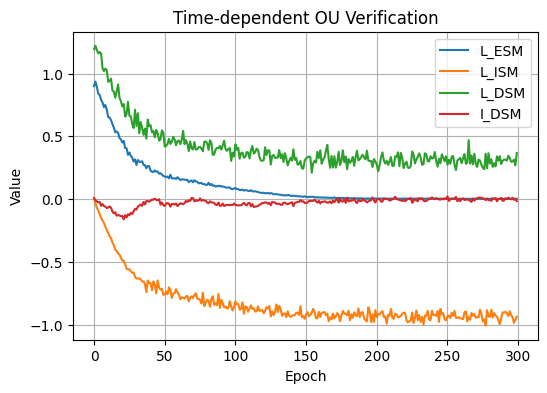

In [4]:
plt.figure(figsize=(6,4))

plt.plot(L_ESM_history, label='L_ESM')
plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Time-dependent OU Verification")

plt.legend()
plt.grid(True)

plt.show()

# Reverse

In [5]:
import numpy as np
import torch
import pandas as pd
# ============================================================
# Reverse OU Sampling: compare steps / dt with fixed T
# ============================================================

model.eval()

num_samples = 5000

# fixed OU setting
T = 5.0
beta = 1.0
mu0 = 10.0
var0 = 2.0
sigma = np.sqrt(2.0)

step_list = [500, 1000, 2000, 5000]

results = []

for steps in step_list:

    dt = T / steps   # keep steps * dt = T = 5

    # ========================================================
    # Start from p_T
    # ========================================================

    a_T = np.exp(-beta * T)

    cond_var_T = (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * T))
    )

    mu_T = a_T * mu0

    var_T = (
        (a_T**2) * var0
        + cond_var_T
    )

    x = (
        torch.randn(num_samples, 1)
        * np.sqrt(var_T)
        + mu_T
    )

    # ========================================================
    # Reverse SDE: x_T -> x_0
    # ========================================================

    with torch.no_grad():

        for i in range(steps):

            t_now = T - i * dt
            t_now = max(t_now, 1e-5)

            t_tensor = torch.ones_like(x) * t_now

            score = model(x, t_tensor)

            noise = torch.randn_like(x)

            x = (
                x
                + (beta * x + sigma**2 * score) * dt
                + sigma * np.sqrt(dt) * noise
            )

    samples_reverse = x.cpu().numpy().flatten()

    results.append({
        "steps": steps,
        "dt": dt,
        "steps*dt": steps * dt,
        "reverse_mean": samples_reverse.mean(),
        "reverse_std": samples_reverse.std(),
        "target_mean": mu0,
        "target_std": np.sqrt(var0),
        "mean_error": abs(samples_reverse.mean() - mu0),
        "std_error": abs(samples_reverse.std() - np.sqrt(var0)),
    })

df_results = pd.DataFrame(results)
df_results

,steps,dt,steps*dt,reverse_mean,reverse_std,target_mean,target_std,mean_error,std_error
0,500,0.0100,5.0,10.020638,1.424406,10.0,1.414214,0.020638,0.010192
1,1000,0.0050,5.0,10.013337,1.451526,10.0,1.414214,0.013337,0.037312
2,2000,0.0025,5.0,10.019374,1.436746,10.0,1.414214,0.019374,0.022532
3,5000,0.0010,5.0,10.056014,1.433926,10.0,1.414214,0.056014,0.019713


,steps,dt,steps*dt,t_eval,reverse_mean,reverse_std,L_ESM,L_DSM,L_ISM,I_DSM
0,500,0.0100,5.0,0.0100,10.036207,1.444043,0.007095,50.352421,-0.481383,0.109099
1,1000,0.0050,5.0,0.0050,9.986988,1.429239,0.006426,101.302780,-0.484406,-0.048192
2,2000,0.0025,5.0,0.0025,10.025401,1.429332,0.006391,197.868195,-0.485497,-0.125910
3,5000,0.0010,5.0,0.0010,9.998313,1.413775,0.006200,502.991486,-0.497785,-0.100828


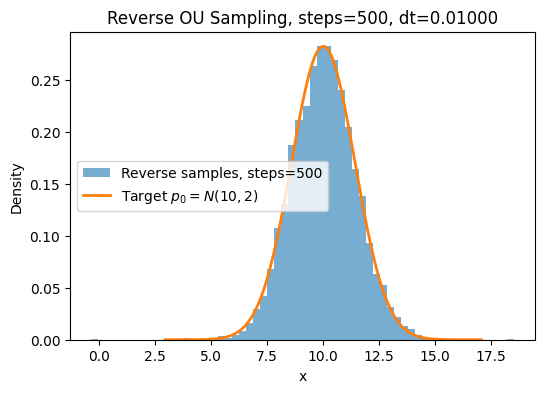

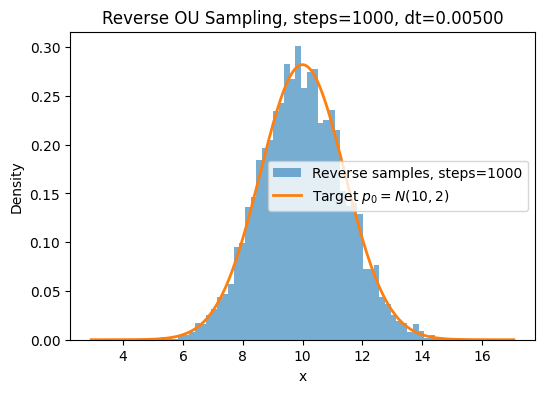

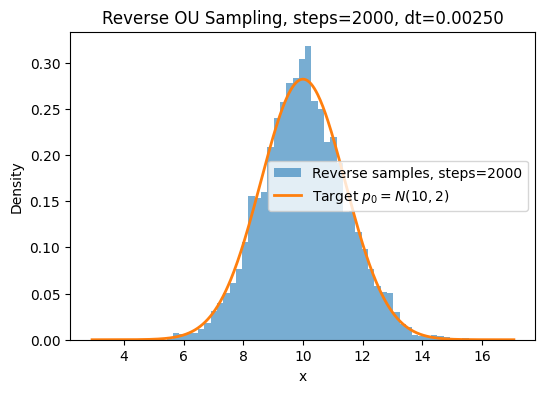

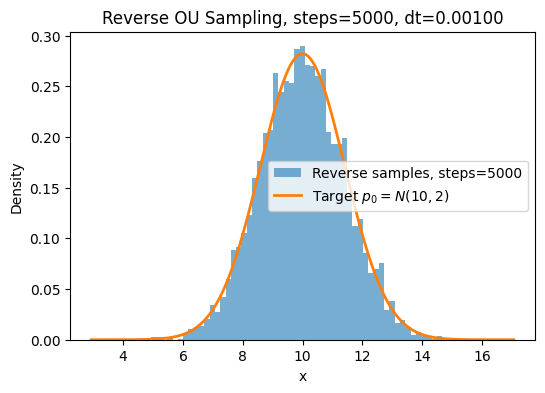

In [6]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Setting
# ============================================================

model.eval()

device = next(model.parameters()).device

num_samples = 5000
T = 5.0

beta = 1.0
mu0 = 10.0
var0 = 2.0
std0 = np.sqrt(var0)

sigma = np.sqrt(2.0)

step_list = [500, 1000, 2000, 5000]

# ============================================================
# Helper: OU marginal parameters
# ============================================================

def ou_params(t):
    a_t = np.exp(-beta * t)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * t))
    )

    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    return a_t, cond_var_t, mu_t, var_t


# ============================================================
# Helper: calculate losses at x_t, t
# ============================================================

def compute_losses(model, x_eval, t_now):
    x_eval = x_eval.clone().detach().requires_grad_(True)
    t_tensor = torch.ones_like(x_eval) * t_now

    pred_score = model(x_eval, t_tensor)

    a_t, cond_var_t, mu_t, var_t = ou_params(t_now)

    # marginal score: ∇ log p_t(x_t)
    marginal_score = -(x_eval - mu_t) / var_t

    # posterior x0 | xt
    post_mean = (
        mu0
        + (a_t * var0 / var_t)
        * (x_eval - mu_t)
    )

    post_var = (
        var0
        - (a_t**2 * var0**2) / var_t
    )

    x0_post = (
        post_mean
        + torch.sqrt(torch.tensor(post_var, device=device, dtype=x_eval.dtype))
        * torch.randn_like(post_mean)
    )

    # conditional score: ∇ log p(x_t | x_0)
    cond_score = -(x_eval - a_t * x0_post) / cond_var_t

    # ESM loss
    L_ESM = ((pred_score - marginal_score) ** 2).mean()

    # DSM loss
    L_DSM = ((pred_score - cond_score) ** 2).mean()

    # ISM loss = E[ ||sθ||^2 + 2 div sθ ]
    grad_score = torch.autograd.grad(
        outputs=pred_score.sum(),
        inputs=x_eval,
        create_graph=False,
        retain_graph=False
    )[0]

    L_ISM = (pred_score**2 + 2 * grad_score).mean()

    # DSM indicator
    # 如果你之前定義的 I_DSM 不是這個，只要改這一行
    I_DSM = (pred_score**2- pred_score * cond_score).mean()


    return {
        "L_ESM": L_ESM.item(),
        "L_DSM": L_DSM.item(),
        "L_ISM": L_ISM.item(),
        "I_DSM": I_DSM.item(),
    }


# ============================================================
# Main experiment
# ============================================================

results = []
sample_dict = {}

for steps in step_list:

    dt = T / steps

    # start from p_T
    a_T, cond_var_T, mu_T, var_T = ou_params(T)

    x = (
        torch.randn(num_samples, 1, device=device)
        * np.sqrt(var_T)
        + mu_T
    )

    x_eval_for_loss = None
    t_eval_for_loss = None

    with torch.no_grad():

        for i in range(steps):

            t_now = T - i * dt

            # save the last positive-time state for loss calculation
            if i == steps - 1:
                x_eval_for_loss = x.clone().detach()
                t_eval_for_loss = t_now

            t_tensor = torch.ones_like(x) * t_now
            score = model(x, t_tensor)
            noise = torch.randn_like(x)

            x = (
                x
                + (beta * x + sigma**2 * score) * dt
                + sigma * np.sqrt(dt) * noise
            )

    samples_reverse = x.detach().cpu().numpy().flatten()
    sample_dict[steps] = samples_reverse

    losses = compute_losses(model, x_eval_for_loss, t_eval_for_loss)

    results.append({
        "steps": steps,
        "dt": dt,
        "steps*dt": steps * dt,
        "t_eval": t_eval_for_loss,
        "reverse_mean": samples_reverse.mean(),
        "reverse_std": samples_reverse.std(),
        **losses
    })


df_results = pd.DataFrame(results)
display(df_results)


# ============================================================
# Plot four figures
# ============================================================

x_grid = np.linspace(mu0 - 5 * std0, mu0 + 5 * std0, 500)
p0_density = (
    1 / np.sqrt(2 * np.pi * var0)
    * np.exp(-(x_grid - mu0)**2 / (2 * var0))
)

for steps in step_list:

    plt.figure(figsize=(6, 4))

    plt.hist(
        sample_dict[steps],
        bins=60,
        density=True,
        alpha=0.6,
        label=f"Reverse samples, steps={steps}"
    )

    plt.plot(
        x_grid,
        p0_density,
        linewidth=2,
        label=r"Target $p_0=N(10,2)$"
    )

    plt.title(f"Reverse OU Sampling, steps={steps}, dt={T/steps:.5f}")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

In [7]:
t_eval_for_loss = 1.0

a_eval, cond_var_eval, mu_eval, var_eval = ou_params(t_eval_for_loss)

x_eval_for_loss = (
    torch.randn(num_samples, 1, device=device)
    * np.sqrt(var_eval)
    + mu_eval
)

losses = compute_losses(model, x_eval_for_loss, t_eval_for_loss)

,steps,dt,steps*dt,loss_eval_t,reverse_mean,reverse_std,L_ESM,L_DSM,L_ISM,I_DSM
0,500,0.0100,5.0,1.0,9.972131,1.417602,0.003343,0.282934,-0.859646,-0.026208
1,1000,0.0050,5.0,1.0,10.005482,1.428570,0.003148,0.267458,-0.904709,-0.019092
2,2000,0.0025,5.0,1.0,9.987720,1.411867,0.003718,0.269228,-0.863289,-0.029162
3,5000,0.0010,5.0,1.0,10.031087,1.442456,0.003251,0.277920,-0.854228,-0.020457


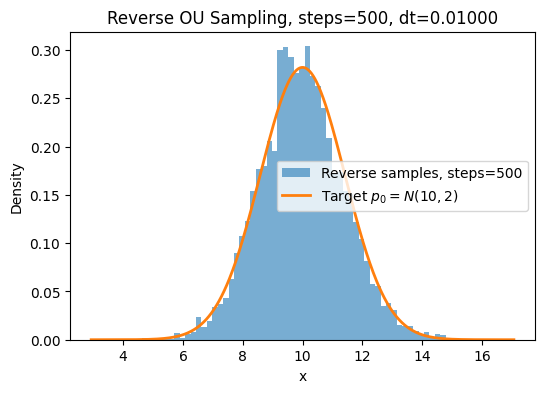

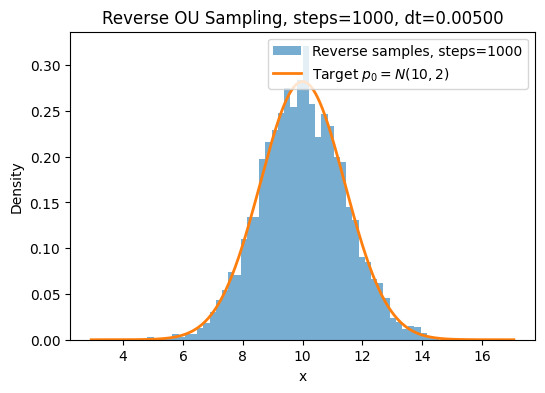

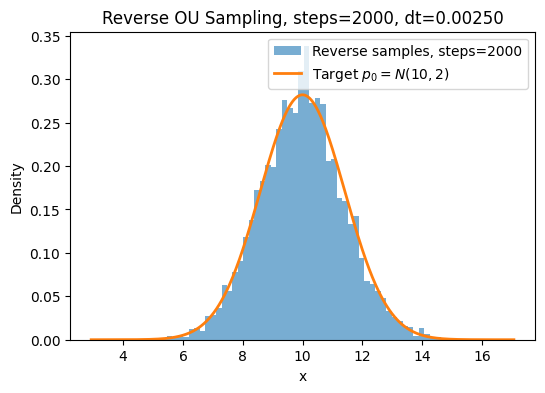

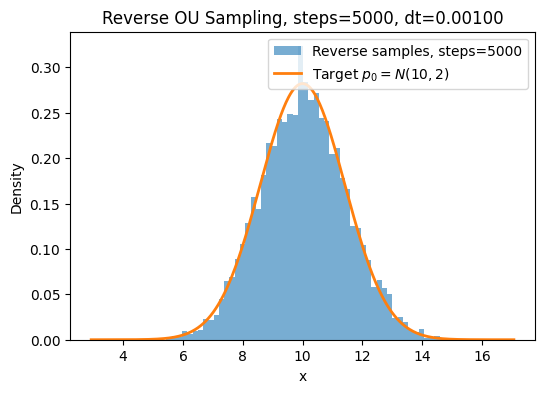

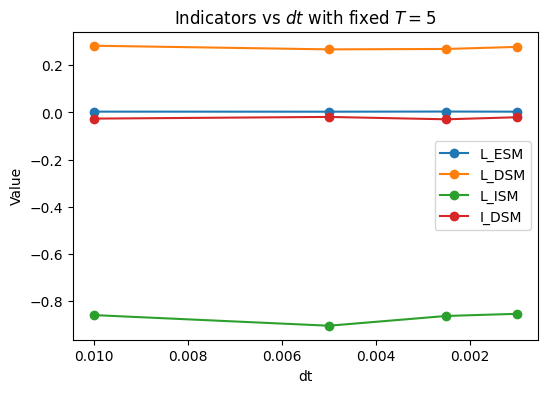

In [8]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Setting
# ============================================================

model.eval()
device = next(model.parameters()).device

num_samples = 5000

T = 5.0
beta = 1.0
mu0 = 10.0
var0 = 2.0
std0 = np.sqrt(var0)
sigma = np.sqrt(2.0)

step_list = [500, 1000, 2000, 5000]

# fixed loss evaluation time
t_eval_for_loss = 1.0


# ============================================================
# OU marginal parameters
# ============================================================

def ou_params(t):
    a_t = np.exp(-beta * t)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - np.exp(-2 * beta * t))
    )

    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    return a_t, cond_var_t, mu_t, var_t


# ============================================================
# Compute losses
# ============================================================

def compute_losses(model, x_eval, t_now):
    x_eval = x_eval.clone().detach().requires_grad_(True)
    t_tensor = torch.ones_like(x_eval) * t_now

    pred_score = model(x_eval, t_tensor)

    a_t, cond_var_t, mu_t, var_t = ou_params(t_now)

    # marginal score: ∇ log p_t(x_t)
    marginal_score = -(x_eval - mu_t) / var_t

    # posterior x0 | xt
    post_mean = (
        mu0
        + (a_t * var0 / var_t)
        * (x_eval - mu_t)
    )

    post_var = (
        var0
        - (a_t**2 * var0**2) / var_t
    )

    x0_post = (
        post_mean
        + torch.sqrt(torch.tensor(post_var, device=device, dtype=x_eval.dtype))
        * torch.randn_like(post_mean)
    )

    # conditional score: ∇ log p(x_t | x0)
    cond_score = -(x_eval - a_t * x0_post) / cond_var_t

    # ESM loss
    L_ESM = ((pred_score - marginal_score) ** 2).mean()

    # DSM loss
    L_DSM = ((pred_score - cond_score) ** 2).mean()

    # ISM loss = E[ ||sθ||² + 2 div sθ ]
    grad_score = torch.autograd.grad(
        outputs=pred_score.sum(),
        inputs=x_eval,
        create_graph=False,
        retain_graph=False
    )[0]

    L_ISM = (pred_score**2 + 2 * grad_score).mean()

    # DSM indicator
    I_DSM = (pred_score**2- pred_score * cond_score).mean()
    
    return {
        "L_ESM": L_ESM.item(),
        "L_DSM": L_DSM.item(),
        "L_ISM": L_ISM.item(),
        "I_DSM": I_DSM.item(),
    }


# ============================================================
# Main experiment
# ============================================================

results = []
sample_dict = {}

for steps in step_list:

    dt = T / steps

    # start from p_T
    a_T, cond_var_T, mu_T, var_T = ou_params(T)

    x = (
        torch.randn(num_samples, 1, device=device)
        * np.sqrt(var_T)
        + mu_T
    )

    # reverse OU sampling
    with torch.no_grad():

        for i in range(steps):

            t_now = T - i * dt
            t_now = max(t_now, 1e-5)

            t_tensor = torch.ones_like(x) * t_now
            score = model(x, t_tensor)
            noise = torch.randn_like(x)

            x = (
                x
                + (beta * x + sigma**2 * score) * dt
                + sigma * np.sqrt(dt) * noise
            )

    samples_reverse = x.detach().cpu().numpy().flatten()
    sample_dict[steps] = samples_reverse

    # fixed x_eval sampled from p_{t_eval}
    a_eval, cond_var_eval, mu_eval, var_eval = ou_params(t_eval_for_loss)

    x_eval_for_loss = (
        torch.randn(num_samples, 1, device=device)
        * np.sqrt(var_eval)
        + mu_eval
    )

    losses = compute_losses(model, x_eval_for_loss, t_eval_for_loss)

    results.append({
        "steps": steps,
        "dt": dt,
        "steps*dt": steps * dt,
        "loss_eval_t": t_eval_for_loss,
        "reverse_mean": samples_reverse.mean(),
        "reverse_std": samples_reverse.std(),
        **losses
    })


df_results = pd.DataFrame(results)
display(df_results)


# ============================================================
# Plot four reverse sampling figures
# ============================================================

x_grid = np.linspace(mu0 - 5 * std0, mu0 + 5 * std0, 500)

p0_density = (
    1 / np.sqrt(2 * np.pi * var0)
    * np.exp(-(x_grid - mu0)**2 / (2 * var0))
)

for steps in step_list:

    plt.figure(figsize=(6, 4))

    plt.hist(
        sample_dict[steps],
        bins=60,
        density=True,
        alpha=0.6,
        label=f"Reverse samples, steps={steps}"
    )

    plt.plot(
        x_grid,
        p0_density,
        linewidth=2,
        label=r"Target $p_0=N(10,2)$"
    )

    plt.title(f"Reverse OU Sampling, steps={steps}, dt={T/steps:.5f}")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


# ============================================================
# Plot indicators vs dt
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(df_results["dt"], df_results["L_ESM"], marker="o", label="L_ESM")
plt.plot(df_results["dt"], df_results["L_DSM"], marker="o", label="L_DSM")
plt.plot(df_results["dt"], df_results["L_ISM"], marker="o", label="L_ISM")
plt.plot(df_results["dt"], df_results["I_DSM"], marker="o", label="I_DSM")

plt.gca().invert_xaxis()
plt.xlabel("dt")
plt.ylabel("Value")
plt.title(r"Indicators vs $dt$ with fixed $T=5$")
plt.legend()
plt.show()